In [1]:
# y = wx+b --> single variable linear regression
# y = w1x1+w2x2+... + b ---> multivariable linear reg.
# y = w1x^3 + w2x^10 + ... + b ---> polynomial lr.

## Linear Reg.

In [2]:
# y = w1x^3 + w2x^10 + ... + b ---> y = w1z1+w2z2+... + b

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
os.chdir(r"K:\Learning-AI-Engineer-Course\05_Machine Learning\00_Datasets")
print(os.getcwd())

K:\Learning-AI-Engineer-Course\05_Machine Learning\00_Datasets


In [5]:
df = pd.read_csv('.\Advertising.csv')

In [6]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [7]:
df.shape

(200, 4)

In [8]:
df.tail()

,TV,radio,newspaper,sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,13.4


In [9]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [11]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


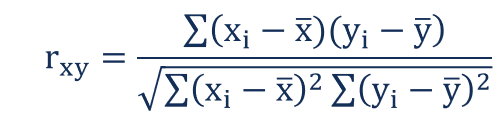

In [16]:
from IPython.display import Image
Image('K:\\Learning-AI-Engineer-Course\\05_Machine Learning\\02_Linear_Regression\\correlation1.png')

In [17]:
# corr >>> -1 <= corr <= 1

In [18]:
#TV, radio, newspaper, sales
#رابطه ی میزان فروش کالا
#با میزان هزینه تبلیغاتی در تلوزیون رادیو و روزنامه
#چگونه است؟

In [19]:
#اگر من در رادیو x1
#در روزنامه x2
#در تلویزون x4
#هزینه تبلیغات کنم
#میزان فروش من چقدر خواهد بود؟

In [20]:
#label, target: sales
#features : TV, radio, newspaper

In [21]:
x = df.drop('sales', axis=1)
y = df['sales']

In [22]:
x

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [23]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [25]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [28]:
x_train.shape

(140, 3)

In [29]:
x_test.shape

(60, 3)

In [30]:
#row 1
#row 2
#row 3
#row 4
#row 5

#test_size = 0.2 ---> 1

#random_state = 42 ---> 2 --> test! ---> mse: 0.1
#random_state = 100 --> 5 --> test!

In [32]:
# y = w1*TV + w2*Radio + w3*Newspaper

from sklearn.linear_model import LinearRegression
model= LinearRegression()

#def LR_x_train, y_train):
        #Gradient Descent!
        #w1 ?
        #w2 ?
        #w3 ?
        #return w1x1 + w2x2 + w3x3 


In [33]:
x_train.shape

(140, 3)

In [34]:
#fit ---> GD -->
#y = w1*TV + w2*Radio + w3*Newspaper
# randomly: y = 0.01*TV + 0.3*Radio + 1.5*Newspaper ---> GD

In [36]:
model.fit(x_train, y_train) ##OBTAINING WEIGHTS AND BIAS.(W1, W2, W3)

LinearRegression()

### In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.


In [38]:
model.coef_

array([0.04405928, 0.1992875 , 0.00688245])

In [40]:
pd.DataFrame(model.coef_, x.columns, columns=['Weights'])

,Weights
TV,0.044059
radio,0.199287
newspaper,0.006882


In [41]:
#sales = w1*TV + w2*radio + w3*newspaper
#sales = 0.04*TV + 0.19*radio + 0.006*newspaper

In [42]:
# prediction test data / test/ Evaluation
y_pred = model.predict(x_test)
#y_pred = 0.04*TV + 0.19*radio + 0.006*newspaper

In [43]:
y_pred

array([16.5653963 , 21.18822792, 21.55107058, 10.88923816, 22.20231988,
       13.35556872, 21.19692502,  7.35028523, 13.27547079, 15.12449511,
        9.01443026,  6.52542825, 14.30205991,  8.97026042,  9.45679576,
       12.00454351,  8.91549403, 16.15619251, 10.29582883, 18.72473553,
       19.76821818, 13.77469028, 12.49638908, 21.53501762,  7.60860741,
        5.6119801 , 20.91759483, 11.80627665,  9.08076637,  8.51412012,
       12.17604891,  9.9691939 , 21.73008956, 12.77770578, 18.1011362 ,
       20.07590796, 14.26202556, 20.93826535, 10.83938827,  4.38190607,
        9.51332406, 12.40486324, 10.17045434,  8.09081363, 13.16388427,
        5.2243552 ,  9.28893833, 14.09330719,  8.69024497, 11.66119763,
       15.71848432, 11.63156862, 13.35360735, 11.1531472 ,  6.33636845,
        9.76157954,  9.4195714 , 24.25516546,  7.69519137, 12.15317572])

In [44]:
x_test

,TV,radio,newspaper
95,163.3,31.6,52.9
15,195.4,47.7,52.9
30,292.9,28.3,43.2
158,11.7,36.9,45.2
128,220.3,49.0,3.2
115,75.1,35.0,52.7
69,216.8,43.9,27.2
170,50.0,11.6,18.4
174,222.4,3.4,13.1
45,175.1,22.5,31.5


In [46]:
#loss functions
from sklearn import metrics
MAE = metrics.mean_absolute_error(y_test, y_pred)
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

In [48]:
print('mae: ', MAE)

mae:  1.5116692224549084


In [49]:
print('mse: ', MSE)

mse:  3.79679723671522


In [50]:
print('rmse: ', RMSE)

rmse:  1.9485372043446387


In [51]:
test_residual = y_test-y_pred
test_residual

95     0.334604
15     1.211772
30    -0.151071
158   -3.589238
128    2.497680
115   -0.755569
69     1.103075
170    1.049715
174   -1.775471
45    -0.224495
66     0.485570
182    2.174572
165   -2.402060
78    -3.670260
186    0.843204
177   -0.304544
56    -3.415494
152    0.443807
82     1.004171
68     0.175264
124   -0.068218
16    -1.274690
148   -1.596389
93     0.664982
65     1.691393
60     2.488020
84     0.782405
67     1.593723
125    1.519234
132   -2.814120
9     -1.576049
18     1.330806
55     1.969910
75    -4.077706
150   -2.001136
104    0.624092
135   -2.662026
137   -0.138265
164    1.060612
76     2.518094
79     1.486676
197    0.395137
38    -0.070454
24     1.609186
122   -1.563884
195    2.375645
29     1.211062
19     0.506693
143    1.709755
86     0.338802
114   -1.118484
173    0.068431
5     -6.153607
126   -4.553147
117    3.063632
73     1.238420
140    1.480429
98     1.144835
172   -0.095191
96    -0.453176
Name: sales, dtype: float64

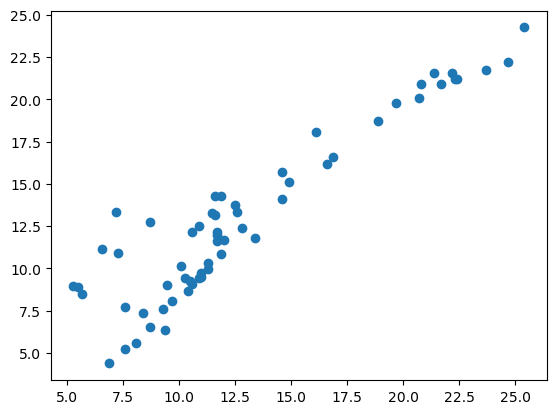

In [52]:
plt.scatter(y_test, y_pred)
plt.show()

In [54]:
from joblib import dump, load

In [55]:
dump(model, 'Sales.joblib')

['Sales.joblib']

In [56]:
pwd|

'K:\\Learning-AI-Engineer-Course\\05_Machine Learning\\00_Datasets'

In [57]:
ls

 Volume in drive K has no label.
 Volume Serial Number is 4A8E-9103

 Directory of K:\Learning-AI-Engineer-Course\05_Machine Learning\00_Datasets

10/05/2025  02:39 PM    <DIR>          .
10/05/2025  02:39 PM    <DIR>          ..
10/05/2025  10:52 AM             4,213 Advertising.csv
10/05/2025  02:39 PM               913 Sales.joblib
               2 File(s)          5,126 bytes
               2 Dir(s)  42,554,757,120 bytes free


In [58]:
# Loading model
sales_model_2 = load('Sales.joblib')

In [59]:
#tv: 150, radio:25, newspaper:10
adv_camp = [[150, 25, 10]]
sales_model_2.predict(adv_camp)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([14.36885318])